In [7]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import glob
from pathlib import Path
%matplotlib inline

In [8]:
def frame_to_y(frame):
    """
    turn BGR to YUV and take Y chan
    """
    yuv = cv2.cvtColor(frame, cv2.COLOR_BGR2YUV)
    y = yuv[:, :, 0]
    return y.astype(np.int16)

In [9]:
def valid_search_position(cand_x, cand_y, mb_x, mb_y, width, height,search_range, block_size):
    dx = cand_x - mb_x
    dy = cand_y - mb_y

    if abs(dx) > search_range or abs(dy) > search_range:
        return False

    return  (
        0 <= cand_x and
        0 <= cand_y and
        cand_x + block_size <= width and
        cand_y + block_size <= height
    )

class MBestimator:
    def __init__(self, block_size=16, search_range=7):
        self.block_size = block_size
        self.search_range = search_range

        self.get_block = lambda f,x,y,bs: f[y:y + bs, x:x + bs]
        
    def full_search(self, cf, pf,mb_x, mb_y):
        height, width = cf.shape
        bs = self.block_size
        R = self.search_range

        best_sad = float("inf")
        best_dx = 0
        best_dy = 0
        sad_count = 0

        for dy in range(-R, R + 1):
            for dx in range(-R, R + 1):
                cand_x = mb_x + dx
                cand_y = mb_y + dy

                if not self._valid_search_position(cand_x, cand_y, mb_x, mb_y, width, height):
                    continue

                value = self._eval_candidate(self.get_block(cf, mb_x, mb_y, bs), pf, cand_x, cand_y)
                sad_count += 1

                if value < best_sad:
                    best_sad = value
                    best_dx = dx
                    best_dy = dy

        return best_dx, best_dy, best_sad, sad_count
    
    def three_step_search(self,cf, pf,mb_x, mb_y):
        height, width = cf.shape
        bs = self.block_size
        R = self.search_range

        step = 2 ** int(np.floor(np.log2(R + 1)) - 1)
        step = max(1, step)

        cx = mb_x
        cy = mb_y

        best_sad = float("inf")
        best_x = cx
        best_y = cy

        sad_count = 0
        visited = set()

        while step >= 1:
            offsets = [
                (0, 0),
                (-step, -step), (0, -step), (step, -step),
                (-step, 0),                  (step, 0),
                (-step, step),  (0, step),  (step, step),
            ]

            local_best_sad = float("inf")
            local_best_x = cx
            local_best_y = cy

            for ox, oy in offsets:
                cand_x = cx + ox
                cand_y = cy + oy

                if (cand_x, cand_y) in visited:
                    continue

                if not self._valid_search_position(cand_x, cand_y, mb_x, mb_y, width, height):
                    continue

                visited.add((cand_x, cand_y))

                value = self._eval_candidate(self.get_block(cf, mb_x, mb_y, bs), pf, cand_x, cand_y)
                sad_count += 1

                if value < local_best_sad:
                    local_best_sad = value
                    local_best_x = cand_x
                    local_best_y = cand_y

            cx = local_best_x
            cy = local_best_y

            if local_best_sad < best_sad:
                best_sad = local_best_sad
                best_x = local_best_x
                best_y = local_best_y

            step //= 2 # new 8 neighbors with half step size based on current best position

        best_dx = best_x - mb_x
        best_dy = best_y - mb_y

        return best_dx, best_dy, best_sad, sad_count
    
    @staticmethod
    def median_mv(mv_field, mb_i, mb_j):
        candidates = []

        if mb_j > 0:
            candidates.append(mv_field[mb_i, mb_j - 1])

        if mb_i > 0:
            candidates.append(mv_field[mb_i - 1, mb_j])

        if mb_i > 0 and mb_j > 0:
            candidates.append(mv_field[mb_i - 1, mb_j - 1])

        if len(candidates) == 0:
            return 0, 0

        candidates = np.array(candidates)

        pred_dx = int(np.median(candidates[:, 0]))
        pred_dy = int(np.median(candidates[:, 1]))

        return pred_dx, pred_dy
    
    def diamond_search_with_init(self, cf, pf,mb_x, mb_y,mv_field,mb_i, mb_j):
        pred_dx, pred_dy = MBestimator.median_mv(mv_field, mb_i, mb_j)
        return self.diamond_search(cf, pf,mb_x, mb_y, pred_dx, pred_dy)
    
    def diamond_search(self, cf, pf,mb_x, mb_y, init_dx=0, init_dy=0):
        """Run large-diamond search followed by small-diamond refinement."""
        height, width = cf.shape
        bs = self.block_size
        R = self.search_range

        curr_block = self.get_block(cf, mb_x, mb_y, bs)

        init_dx = int(np.clip(init_dx, -R, R))
        init_dy = int(np.clip(init_dy, -R, R))

        cx = mb_x + init_dx
        cy = mb_y + init_dy

        if not self._valid_search_position(cx, cy, mb_x, mb_y, width, height):
            cx = mb_x
            cy = mb_y

        large_diamond_offsets = [
            (0, 0),
            (0, -2),
            (-1, -1), (1, -1),
            (-2, 0), (2, 0),
            (-1, 1), (1, 1),
            (0, 2),
        ]
        small_diamond_offsets = [(0, 0), (0, -1), (-1, 0), (1, 0), (0, 1)]

        cost_cache = {}
        sad_count = 0

        def candidate_cost(cand_x, cand_y):
            """Return cached candidate cost and count new search points once."""
            nonlocal sad_count

            if not self._valid_search_position(cand_x, cand_y, mb_x, mb_y, width, height):
                return None

            key = (cand_x, cand_y)
            if key not in cost_cache:
                cost_cache[key] = self._eval_candidate(curr_block, pf, cand_x, cand_y)
                sad_count += 1

            return cost_cache[key]

        while True:
            local_best_sad = float("inf")
            local_best_x = cx
            local_best_y = cy

            for ox, oy in large_diamond_offsets:
                cand_x = cx + ox
                cand_y = cy + oy
                value = candidate_cost(cand_x, cand_y)

                if value is None:
                    continue

                if value < local_best_sad:
                    local_best_sad = value
                    local_best_x = cand_x
                    local_best_y = cand_y

            if local_best_x == cx and local_best_y == cy:
                break

            cx = local_best_x
            cy = local_best_y

        best_sad = float("inf")
        best_x = cx
        best_y = cy

        for ox, oy in small_diamond_offsets:
            cand_x = cx + ox
            cand_y = cy + oy
            value = candidate_cost(cand_x, cand_y)

            if value is None:
                continue

            if value < best_sad:
                best_sad = value
                best_x = cand_x
                best_y = cand_y

        best_dx = best_x - mb_x
        best_dy = best_y - mb_y

        return best_dx, best_dy, best_sad, sad_count
    

    def _valid_search_position(self, cand_x, cand_y, mb_x, mb_y, width, height):
        dx = cand_x - mb_x
        dy = cand_y - mb_y

        if abs(dx) > self.search_range or abs(dy) > self.search_range:
            return False

        return  (
            0 <= cand_x and
            0 <= cand_y and
            cand_x + self.block_size <= width and
            cand_y + self.block_size <= height
        )
    def _eval_candidate(self, curr_block, ref_frame, cand_x, cand_y):
        """Return the per-pixel MSE criterion for one candidate reference block."""
        ref_block = self.get_block(ref_frame, cand_x, cand_y, self.block_size)
        diff = curr_block.astype(np.int32) - ref_block.astype(np.int32)
        return np.mean(diff * diff)

    def _eval_mse(self, curr_block, ref_frame, cand_x, cand_y):
        """Return the per-pixel MSE for one selected reference block."""
        return self._eval_candidate(curr_block, ref_frame, cand_x, cand_y)
    
    def process_frame_pair(self, curr_frame, ref_frame, algorithm, collect_blocks=False):
        """Estimate one frame pair and optionally return per-macroblock match records."""
        height, width = curr_frame.shape
        mb_size = self.block_size

        mv_field = np.zeros((height // mb_size, width // mb_size, 2), dtype=np.int16)

        total_mse_per_pixel = 0.0
        total_search_points = 0
        num_blocks = 0
        block_records = []

        for mb_y in range(0, height, mb_size):
            for mb_x in range(0, width, mb_size):
                mb_i = mb_y // mb_size
                mb_j = mb_x // mb_size

                match algorithm:
                    case "Full Search":
                        dx, dy, sad, count = self.full_search(curr_frame, ref_frame, mb_x, mb_y)
                    case "Three Step Search":
                        dx, dy, sad, count = self.three_step_search(curr_frame, ref_frame, mb_x, mb_y)
                    case "Diamond Search":
                        dx, dy, sad, count = self.diamond_search(curr_frame, ref_frame, mb_x, mb_y)
                    case "Predicted Diamond Search":
                        dx, dy, sad, count = self.diamond_search_with_init(curr_frame, ref_frame, mb_x, mb_y, mv_field, mb_i, mb_j)
                    case _:
                        raise ValueError(f"Unknown algorithm: {algorithm}") # make linter happy

                mv_field[mb_i, mb_j] = [dx, dy]
                ref_x = mb_x + dx
                ref_y = mb_y + dy
                curr_block = self.get_block(curr_frame, mb_x, mb_y, mb_size)
                block_mse = self._eval_mse(curr_block, ref_frame, ref_x, ref_y)
                total_mse_per_pixel += block_mse
                total_search_points += count
                num_blocks += 1

                if collect_blocks:
                    block_records.append({
                        "mb_x": int(mb_x),
                        "mb_y": int(mb_y),
                        "ref_x": int(ref_x),
                        "ref_y": int(ref_y),
                        "dx": int(dx),
                        "dy": int(dy),
                        "block_mse": float(block_mse),
                        "search_points": int(count),
                    })

        average_mse_per_pixel = total_mse_per_pixel / num_blocks
        average_search_points = total_search_points / num_blocks

        if collect_blocks:
            return (average_mse_per_pixel, average_search_points, block_records)

        return (average_mse_per_pixel, average_search_points)

In [ ]:
ALGORITHMS = [
    "Full Search",
    "Three Step Search",
    "Diamond Search",
    "Predicted Diamond Search",
]

def _read_y_frame_pairs(video_path, max_frame_pairs=None):
    """Yield consecutive Y-channel frame pairs from one video file."""
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        raise FileNotFoundError(f"Cannot open video: {video_path}")

    ok, previous = capture.read()
    if not ok:
        capture.release()
        raise ValueError(f"Video has no readable frames: {video_path}")

    previous_y = frame_to_y(previous)
    pair_count = 0

    while max_frame_pairs is None or pair_count < max_frame_pairs:
        ok, current = capture.read()
        if not ok:
            break

        current_y = frame_to_y(current)
        yield current_y, previous_y
        previous_y = current_y
        pair_count += 1

    capture.release()

def _read_y_frame_pair_at(video_path, frame_pair_number):
    """Return the current and previous Y frames for a 1-based frame-pair index."""
    if frame_pair_number < 1:
        raise ValueError("frame_pair_number must be 1 or larger")

    for index, (current_y, previous_y) in enumerate(_read_y_frame_pairs(video_path), start=1):
        if index == frame_pair_number:
            return current_y, previous_y

    raise ValueError(f"Frame pair {frame_pair_number} is not available in {video_path}")

def _peak_frame_rows(video_name, video_results, top_k=1):
    """Find frame pairs with the largest algorithm-reported MSE values."""
    peak_scores = {}

    for algorithm, metrics in video_results.items():
        for frame_index, mse_value in enumerate(metrics["average_mse_per_pixel"], start=1):
            row = peak_scores.setdefault(
                frame_index,
                {
                    "video": video_name,
                    "frame_pair": frame_index,
                    "peak_mse": float(mse_value),
                    "mse_by_algorithm": {},
                },
            )
            row["mse_by_algorithm"][algorithm] = float(mse_value)
            row["peak_mse"] = max(row["peak_mse"], float(mse_value))

    rows = sorted(
        peak_scores.values(),
        key=lambda row: row["peak_mse"],
        reverse=True,
    )
    return rows[:top_k]

def _plot_peak_frame_pairs(video_paths, results, top_k=1):
    """Show both Y frames for high-MSE frame pairs and list algorithm MSE values."""
    peak_rows = []
    video_path_by_name = {Path(path).stem: Path(path) for path in video_paths}

    for video_name, video_results in results.items():
        for row in _peak_frame_rows(video_name, video_results, top_k=top_k):
            row = dict(row)
            row["video_path"] = video_path_by_name[video_name]
            peak_rows.append(row)

    if not peak_rows:
        return None

    fig, axes = plt.subplots(len(peak_rows), 3, figsize=(12, 3.2 * len(peak_rows)))
    if len(peak_rows) == 1:
        axes = np.array([axes])

    for row_index, row in enumerate(peak_rows):
        current_y, previous_y = _read_y_frame_pair_at(row["video_path"], row["frame_pair"])
        image_axes = axes[row_index]

        image_axes[0].imshow(previous_y, cmap="gray", vmin=0, vmax=255)
        image_axes[0].set_title(f'{row["video"]}: Previous Y frame')
        image_axes[0].axis("off")

        image_axes[1].imshow(current_y, cmap="gray", vmin=0, vmax=255)
        image_axes[1].set_title(f'Current Y frame')
        image_axes[1].axis("off")

        table_data = [
            [algorithm, f'{row["mse_by_algorithm"].get(algorithm, float("nan")):.3f}']
            for algorithm in ALGORITHMS
        ]
        image_axes[2].axis("off")
        table = image_axes[2].table(
            cellText=table_data,
            colLabels=["Algorithm", "MSE per pixel"],
            loc="center",
        )
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1.25)
        image_axes[2].set_title(
            f'Peak frame pair #{row["frame_pair"]}\nmax MSE = {row["peak_mse"]:.3f}',
            pad=10,
        )

    fig.tight_layout()
    return fig

def _algorithm_block_records(current_y, previous_y, algorithm, block_size=16, search_range=7):
    """Return per-block raw matching records for one algorithm and frame pair."""
    estimator = MBestimator(block_size=block_size, search_range=search_range)
    frame_mse, search_points, block_records = estimator.process_frame_pair(
        current_y,
        previous_y,
        algorithm,
        collect_blocks=True,
    )

    for record in block_records:
        record["algorithm"] = algorithm
        record["frame_mse"] = float(frame_mse)
        record["frame_search_points"] = float(search_points)

    return block_records

def _peak_block_rows(video_path, video_results, top_n=1, top_k=3, block_size=16, search_range=7):
    """Collect each algorithm's topK high-error block records from topN frame pairs."""
    video_name = Path(video_path).stem
    rows = []

    for frame_row in _peak_frame_rows(video_name, video_results, top_k=top_n):
        current_y, previous_y = _read_y_frame_pair_at(video_path, frame_row["frame_pair"])

        for algorithm in ALGORITHMS:
            block_records = _algorithm_block_records(
                current_y,
                previous_y,
                algorithm,
                block_size=block_size,
                search_range=search_range,
            )
            top_blocks = sorted(
                block_records,
                key=lambda record: record["block_mse"],
                reverse=True,
            )[:top_k]

            for algorithm_block_rank, record in enumerate(top_blocks, start=1):
                row = dict(record)
                row["video"] = video_name
                row["video_path"] = Path(video_path)
                row["frame_pair"] = frame_row["frame_pair"]
                row["algorithm_block_rank"] = algorithm_block_rank
                row["frame_pair_peak_mse"] = frame_row["peak_mse"]
                rows.append(row)

    return rows

ALGORITHM_COLORS = {
    "Full Search": "tab:blue",
    "Three Step Search": "tab:orange",
    "Diamond Search": "tab:green",
    "Predicted Diamond Search": "tab:red",
}

def _draw_algorithm_boxes(ax, block_records, x_key, y_key):
    """Draw each algorithm's selected macroblocks on one shared image axis."""
    for block_record in block_records:
        algorithm_color = ALGORITHM_COLORS[block_record["algorithm"]]
        rect = plt.Rectangle(
            (block_record[x_key], block_record[y_key]),
            BLOCK_SIZE,
            BLOCK_SIZE,
            fill=False,
            edgecolor=algorithm_color,
            linewidth=2,
        )
        ax.add_patch(rect)


def _group_peak_blocks_by_frame(block_rows):
    """Group per-algorithm block records by video and frame pair."""
    grouped = {}
    for row in block_rows:
        key = (row["video"], row["frame_pair"])
        grouped.setdefault(key, []).append(row)
    return grouped

def _plot_peak_block_details(video_paths, results, top_n=1, top_k=3, block_size=16, search_range=7):
    """Visualize all algorithms' topK blocks on shared frame-pair images."""
    block_rows = []
    for video_path in video_paths:
        video_name = Path(video_path).stem
        block_rows.extend(
            _peak_block_rows(
                Path(video_path),
                results[video_name],
                top_n=top_n,
                top_k=top_k,
                block_size=block_size,
                search_range=search_range,
            )
        )

    if not block_rows:
        return None

    grouped_rows = list(_group_peak_blocks_by_frame(block_rows).items())
    fig, axes = plt.subplots(len(grouped_rows), 3, figsize=(18, 4.0 * len(grouped_rows)))
    if len(grouped_rows) == 1:
        axes = np.array([axes])

    for row_index, ((video_name, frame_pair), frame_block_rows) in enumerate(grouped_rows):
        current_y, previous_y = _read_y_frame_pair_at(
            frame_block_rows[0]["video_path"],
            frame_pair,
        )
        row_axes = axes[row_index]

        row_axes[0].imshow(previous_y, cmap="gray", vmin=0, vmax=255)
        _draw_algorithm_boxes(row_axes[0], frame_block_rows, "ref_x", "ref_y")
        row_axes[0].set_title(f"{video_name}: Previous Y frame with matched boxes")
        row_axes[0].axis("off")

        row_axes[1].imshow(current_y, cmap="gray", vmin=0, vmax=255)
        _draw_algorithm_boxes(row_axes[1], frame_block_rows, "mb_x", "mb_y")
        row_axes[1].set_title(f"Frame pair #{frame_pair}: Current Y frame with algorithm boxes")
        row_axes[1].axis("off")

        table_rows = []
        for block_record in frame_block_rows:
            algorithm_label = block_record["algorithm"].replace("Predicted Diamond Search", "Predicted Diamond")
            table_rows.append([
                ALGORITHM_COLORS[block_record["algorithm"]],
                algorithm_label,
                block_record["algorithm_block_rank"],
                f'{block_record["frame_mse"]:.3f}',
                f'{block_record["block_mse"]:.3f}',
                f'({block_record["mb_x"]}, {block_record["mb_y"]})',
                f'({block_record["ref_x"]}, {block_record["ref_y"]})',
                f'({block_record["dx"]}, {block_record["dy"]})',
                block_record["search_points"],
            ])

        row_axes[2].axis("off")
        table = row_axes[2].table(
            cellText=table_rows,
            colLabels=[
                "Color",
                "Alg",
                "Rank",
                "Frame MSE",
                "Block MSE",
                "MB",
                "Ref",
                "MV",
                "Search",
            ],
            loc="center",
        )
        table.auto_set_font_size(False)
        rank_label = "Algorithm block rank"
        table.set_fontsize(6)
        table.scale(1, 1.2)
        table.auto_set_column_width(col=list(range(9)))
        for row_offset, block_record in enumerate(frame_block_rows, start=1):
            table[row_offset, 0].get_text().set_color(ALGORITHM_COLORS[block_record["algorithm"]])
            table[row_offset, 0].get_text().set_weight("bold")
        row_axes[2].set_title(
            f"Worst block details: each algorithm, top {top_k} block(s)",
            pad=10,
        )

    fig.tight_layout()
    return fig

def _plot_video_comparison(video_name, video_results):
    """Plot frame-by-frame MSE quality and search-point cost."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for algorithm, metrics in video_results.items():
        frame_numbers = np.arange(1, len(metrics["average_mse_per_pixel"]) + 1)
        axes[0].plot(frame_numbers, metrics["average_mse_per_pixel"], label=algorithm)
        axes[1].plot(frame_numbers, metrics["average_search_points"], label=algorithm)

    axes[0].set_title(f"{video_name}: MSE per pixel")
    axes[0].set_xlabel("Frame #")
    axes[0].set_ylabel("MSE per pixel")
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title(f"{video_name}: search point number")
    axes[1].set_xlabel("Frame #")
    axes[1].set_ylabel("Search Point Number")
    axes[1].grid(True, alpha=0.3)

    axes[0].legend()
    axes[1].legend()
    fig.tight_layout()
    return fig

def _summary_matrix(summary_rows, metric_key):
    """Convert summary rows into an algorithm-by-video matrix for one metric."""
    videos = sorted({row["video"] for row in summary_rows})
    matrix = {algorithm: [] for algorithm in ALGORITHMS}

    for algorithm in ALGORITHMS:
        for video in videos:
            value = next(
                row[metric_key]
                for row in summary_rows
                if row["algorithm"] == algorithm and row["video"] == video
            )
            matrix[algorithm].append(value)

    return videos, matrix

def _plot_reference_table(summary_rows):
    """Render reference-style metric tables with algorithms as rows and videos as columns."""
    if not summary_rows:
        return None

    table_specs = [
        ("Average MSE per Pixel", "mean_average_mse_per_pixel", "{:.3f}"),
        ("Average Search Point Number", "mean_average_search_points", "{:.2f}"),
    ]
    fig, axes = plt.subplots(len(table_specs), 1, figsize=(10, 4.2))
    if len(table_specs) == 1:
        axes = [axes]

    for ax, (title, metric_key, formatter) in zip(axes, table_specs):
        videos, matrix = _summary_matrix(summary_rows, metric_key)
        headers = ["Algorithm", *videos]
        table_data = [
            [algorithm, *[formatter.format(value) for value in values]]
            for algorithm, values in matrix.items()
        ]

        ax.axis("off")
        table = ax.table(cellText=table_data, colLabels=headers, loc="center")
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 1.3)
        ax.set_title(f"{title} (Frame Distance = 1)", pad=10)

    fig.tight_layout()
    return fig

def run_estimation(video_paths, block_size=16, search_range=7, max_frame_pairs=None, make_plots=True):
    estimator = MBestimator(block_size=block_size, search_range=search_range)
    all_results = {}
    summary_rows = []

    for video_path in video_paths:
        video_path = Path(video_path)
        video_name = video_path.stem
        video_results = {
            algorithm: {
                "average_mse_per_pixel": [],
                "average_search_points": [],
            }
            for algorithm in ALGORITHMS
        }

        for _, (current_y, previous_y) in tqdm(enumerate(
            _read_y_frame_pairs(video_path, max_frame_pairs=max_frame_pairs),
            start=1,
        ),desc=f"Processing {video_name}", unit="frame pair"):
            for algorithm in ALGORITHMS:
                average_mse_per_pixel, average_search_points = estimator.process_frame_pair(
                    current_y,
                    previous_y,
                    algorithm,
                )
                video_results[algorithm]["average_mse_per_pixel"].append(average_mse_per_pixel)
                video_results[algorithm]["average_search_points"].append(average_search_points)

        all_results[video_name] = video_results

        for algorithm, metrics in video_results.items():
            if len(metrics["average_mse_per_pixel"]) == 0:
                continue

            summary_rows.append({
                "video": video_name,
                "algorithm": algorithm,
                "mean_average_mse_per_pixel": float(np.mean(metrics["average_mse_per_pixel"])),
                "mean_average_search_points": float(np.mean(metrics["average_search_points"])),
            })

    return all_results, summary_rows


In [ ]:
import os
BLOCK_SIZE = 16
SEARCH_RANGE = 15

# Link to resource cif http://vip.cs.nctu.edu.tw/resource_seq.html, is deprecated because NCTU(National Chiao Tung University)
# has merged with National Yang-Ming University in 2021.
# but can still be found in the link below.
# https://media.xiph.org/video/derf/
assets_dir = Path('../assets')

y4ms = sorted(glob.glob(str(assets_dir / '*.y4m')))

# Set max_frame_pairs to a small integer while debugging; None processes all available frame pairs.
results, summary_rows = run_estimation(
    y4ms,
    block_size=BLOCK_SIZE,
    search_range=SEARCH_RANGE,
    max_frame_pairs=None,
    make_plots=True,
)

Processing akiyo_cif: 0frame pair [00:00, ?frame pair/s]

Processing bowing_cif: 0frame pair [00:00, ?frame pair/s]

Processing container_cif: 0frame pair [00:00, ?frame pair/s]

: 

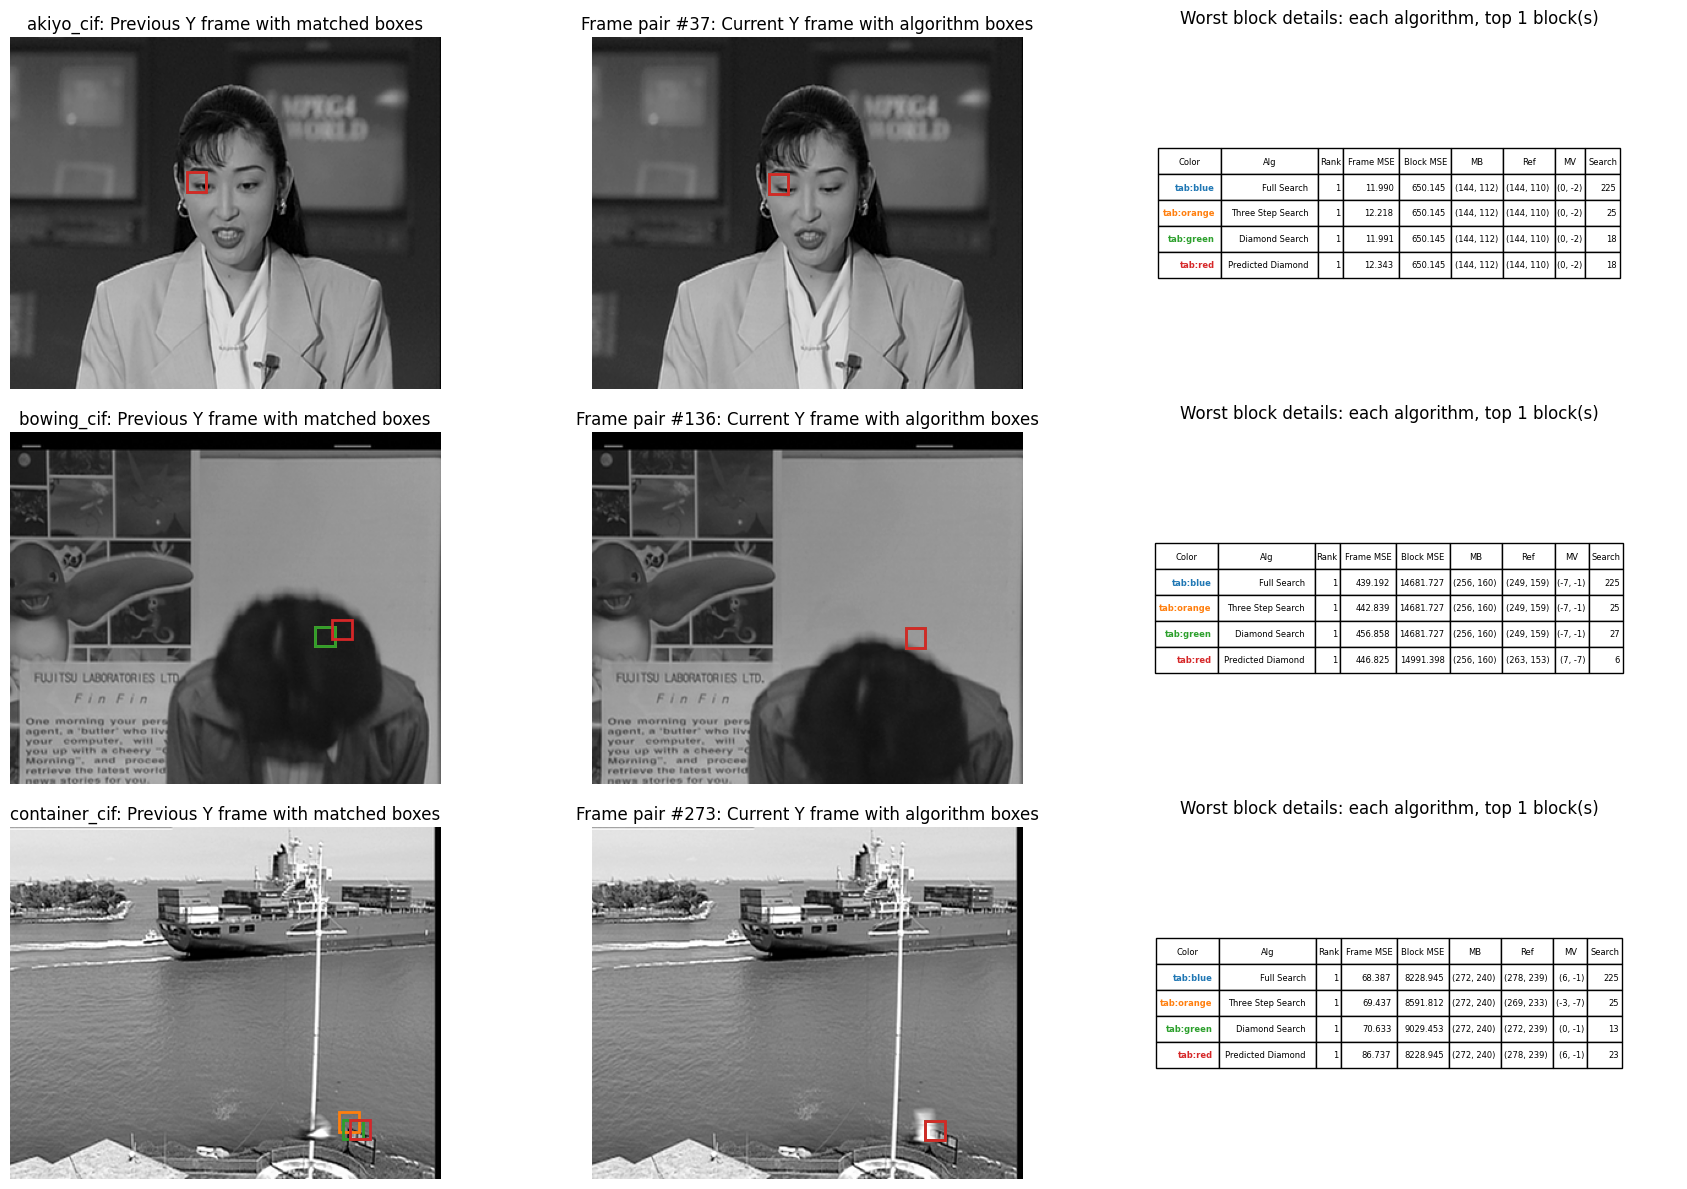

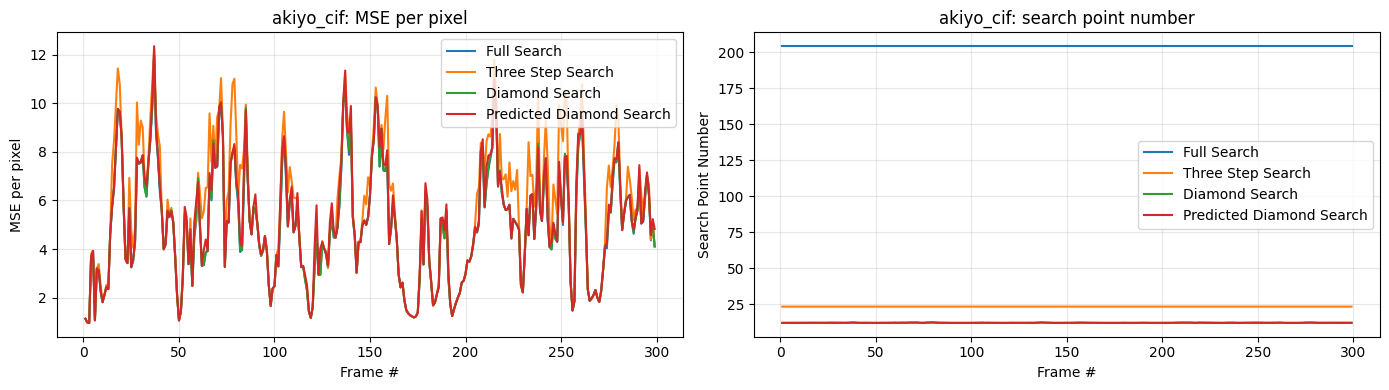

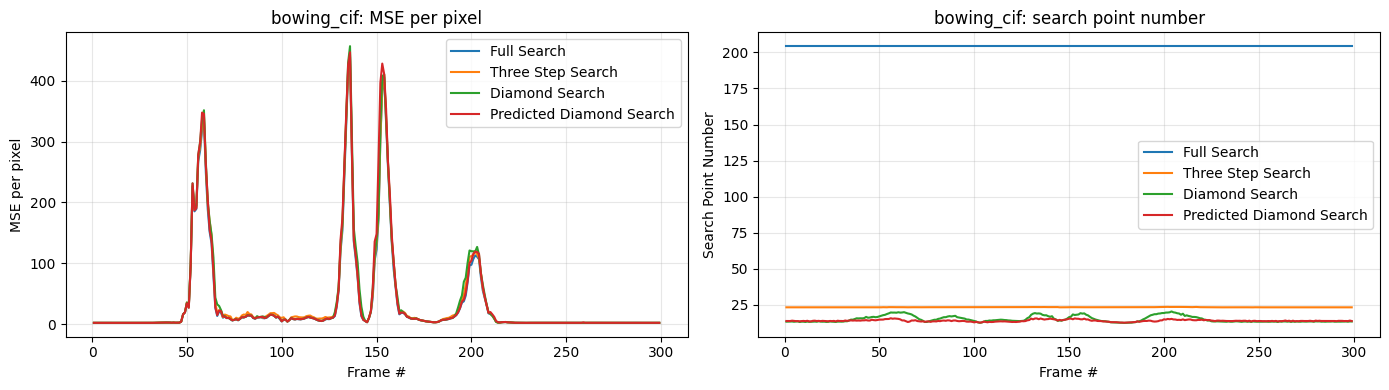

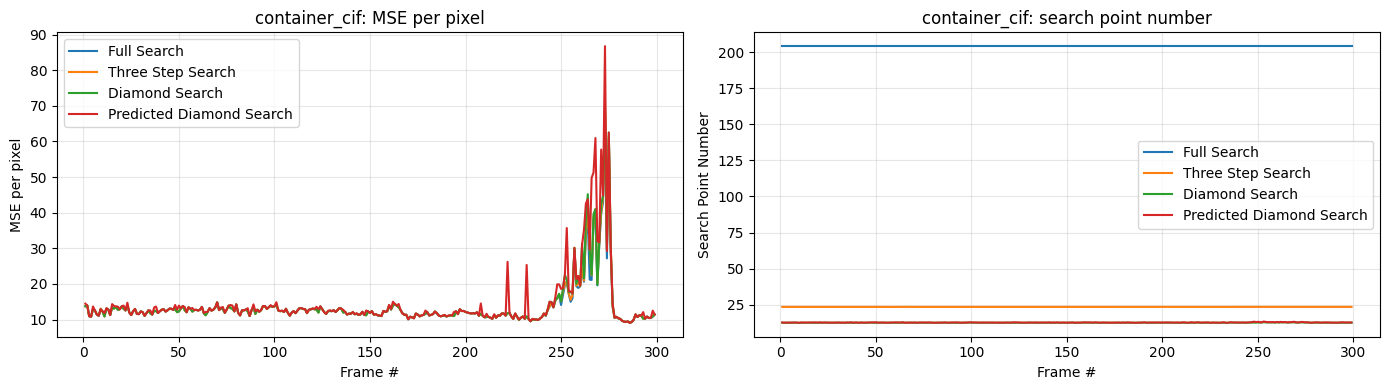

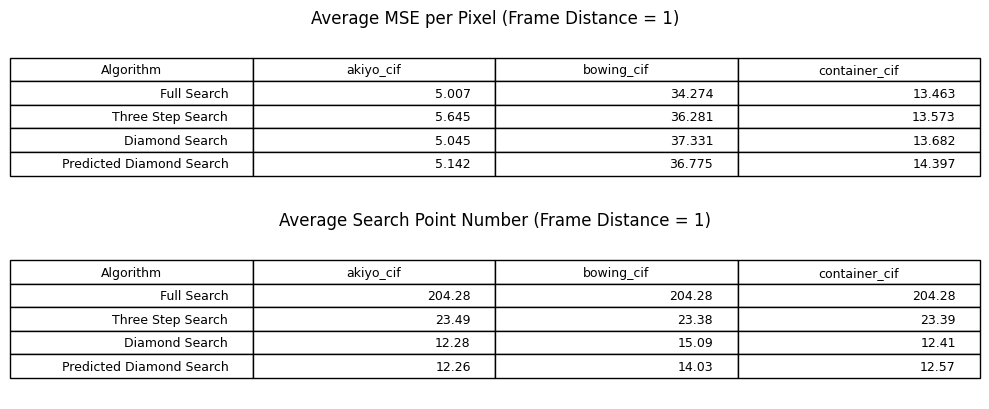

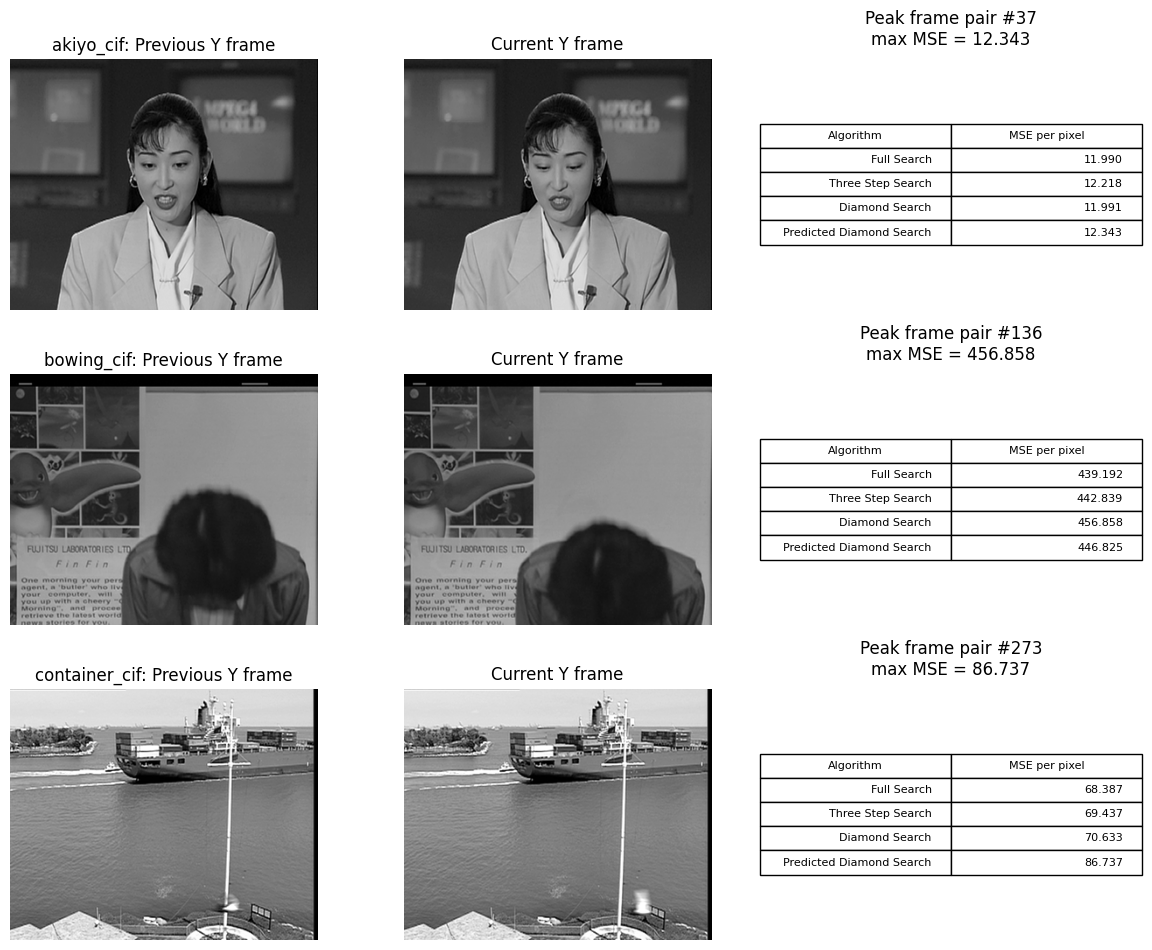

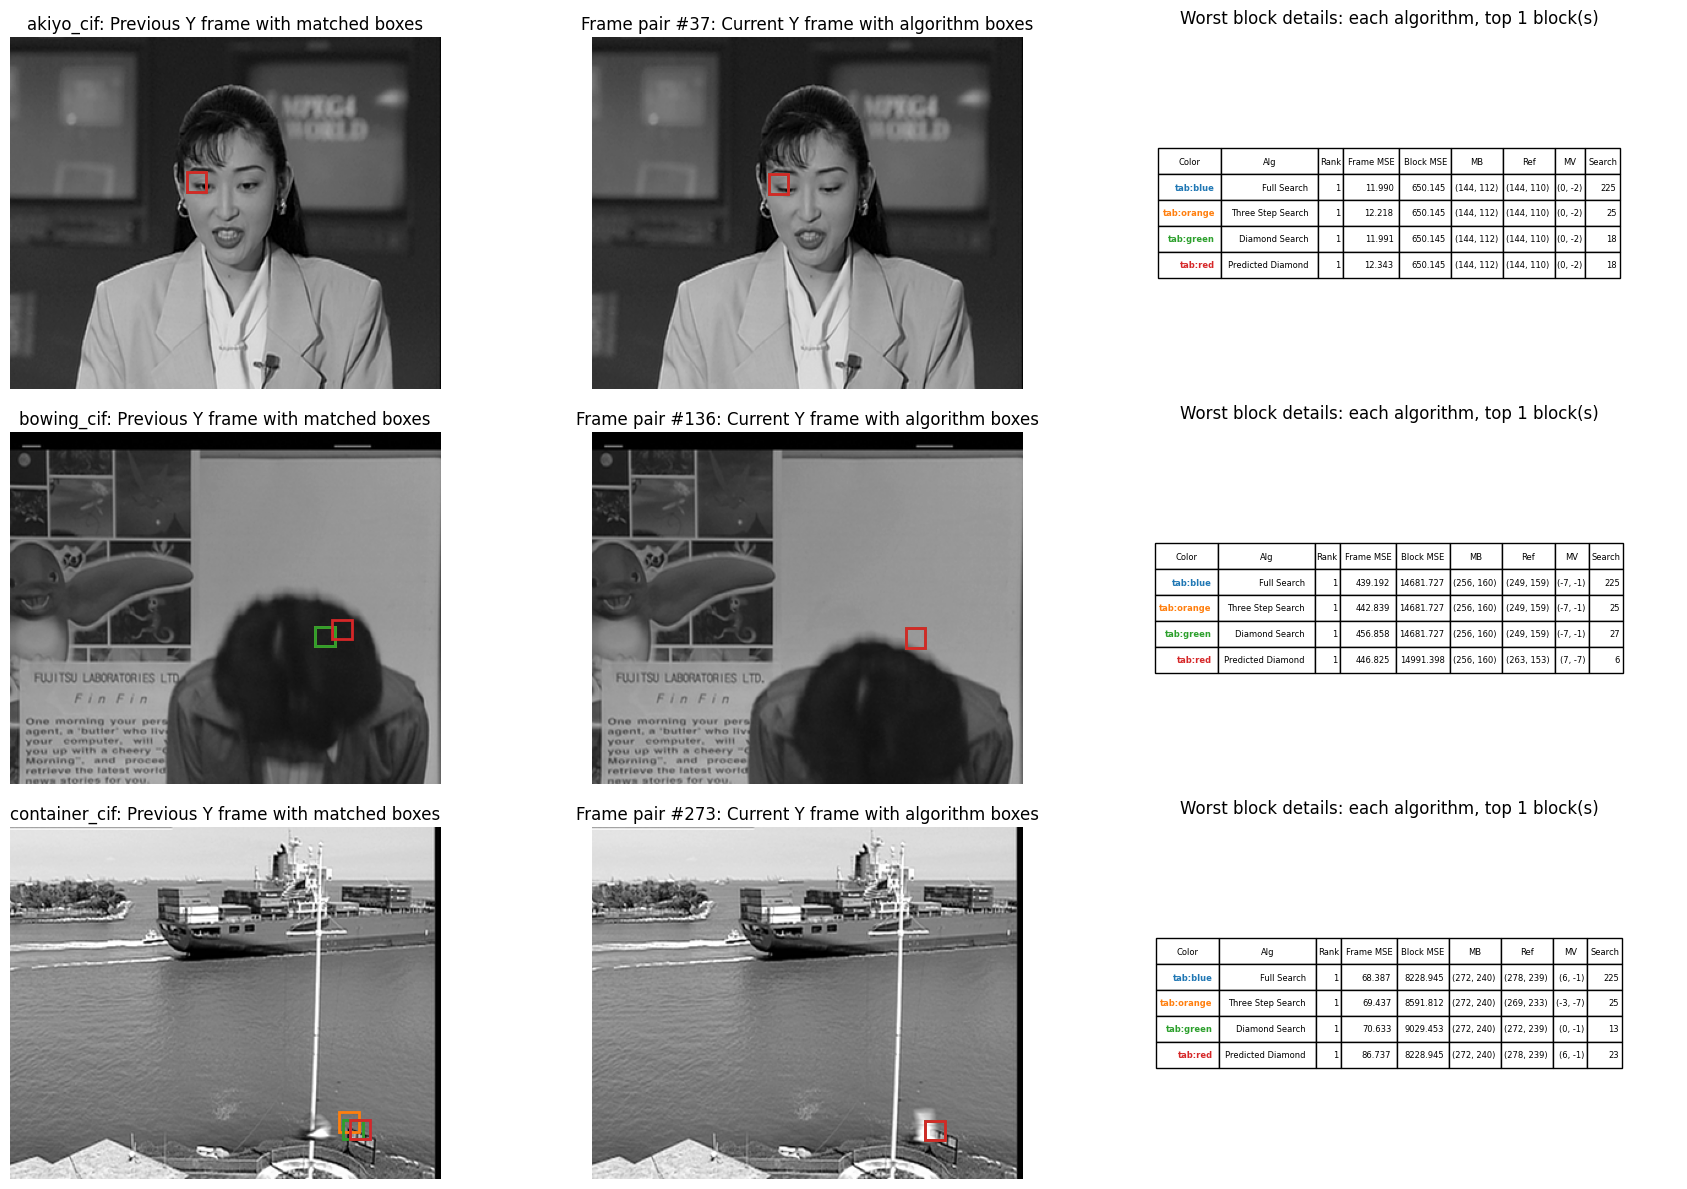

In [12]:
for vid in y4ms:
    video_name = Path(vid).stem
    video_results = results[video_name]
    _plot_video_comparison(video_name, video_results)

_plot_reference_table(summary_rows)

_plot_peak_frame_pairs(y4ms, results, top_k=1)

_plot_peak_block_details(y4ms, results, top_n=1, top_k=1)
